# HMM - Macro-indicators (time-invariant tranisiton probabilities)

- Assume a hidden process of K regimes never directly observed but is determined by the transition matrix.
- We observe our macro-data 


### Emission variable selection

The ENSAE paper used 7 raw variables for emmisions (INDPRO, PPIACO, TCU, UNRATE, UMCSENT, TB3MS, CPI)

Looking at our PCs from both Full Sample and COVID excluded, whilst considering economic sense we select:

1) CUMFNS - Labour market & Credit
2) Slope - Industrial activity & commodities
3) Log_CPI_diff - Inflation 
4) TB3MS_diff - short-term rates 
5) UMCSENT_diff - sentiment important to consider, compare to policy rate
6) UNRATE_diff - Labour market deterioration & financial stress
7) NFCI - Financial coditions and potentially determine stage of business cycle

Must z-score the emissions, with the means and standard deviations calculated excluding the COVID regime. 
We apply this to the full sample, hopefully this will identify a COVID regime as all variables were extreme during COVID.

This will be used in a GaussianHMM with details below

### Number of regimes (K)

Use Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) to determine the number of regimes, we will compromise between the 2 resutls and select the K which makes most economic sense and survives the regime validation.

### K-Means initialisation (inside the HMM fitting call)

Sets initial μ_k where μ_k is the mean vector for regime k of our 7 emmision variables. As a HMM's likelihood surface is not convex at all as the EM algorith finds local optimum, we must have a sensible starting point i.e. use KMeans.

We have 10 restarts i.e. we run the whole fit (K-Means & EM algo) 10 times and keep the run with largest log-likelihood. This is for every candidate k.

### Dirichlet "Sticky" prior (inside HMM fitting call)

We use a sticky Dirichlet prior to put extra weighting on the diagonal entries of our transition matrix as regimes are persistent. The transmat_prior matrix for hmmlearn will control the stickiness. This is a K x K matrix, which we will set diagonal entries to 6 and offdiagonal to 1. This is espeically relevant for macro-regimes and the values are based off the template ENSAE paper. 

### Validation - After eliminating obvious incorrect candidates using AIC and BIC

Show results for regime validation of the survived k's

Numerical stability - We check we have a negative definite log-likelihood hessian.
Persistance - Plot number of months in a regime and compare to expected duration/stationary distribution
Conviction Score - See regime validation

SO fit the model for K=2,3,4,5 then we can run checks

## Data preparation

In [1]:
import os
import numpy as np
import pandas as pd
from fredapi import Fred
from dotenv import load_dotenv
from statsmodels.tsa.stattools import adfuller

load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY'))


def get_series(ticker, name, filepath):
    if os.path.exists(filepath):
        data = pd.read_csv(filepath, index_col=0, parse_dates=True).squeeze()
        data.name = name
    else:
        data = fred.get_series(ticker)
        data.index = pd.to_datetime(data.index)
        data.name = name
        data.to_csv(filepath, header=True)
    return data.ffill().dropna()


def resample_to_monthly(series, method='mean'):
    if method == 'mean':
        return series.resample('ME').mean()
    elif method == 'last':
        return series.resample('ME').last()
    else:
        raise ValueError("method must be 'mean' or 'last'")


def adf_report(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    stationary = result[1] < 0.05
    print(f"{name:20s} ADF={result[0]:8.4f}  p-value={result[1]:.4f}  stationary={'YES' if stationary else 'NO'}")
    return stationary


SERIES_CONFIG = {
    'CUMFNS':   {'name': 'cumfns',  'method': 'mean', 'ensae_name': 'CUMFNS',       'kind': 'level'},
    'T10Y2Y':   {'name': 't10y2y',  'method': 'last', 'ensae_name': 'Slope',        'kind': 'level'},
    'CPIAUCSL': {'name': 'cpi',     'method': 'mean', 'ensae_name': 'Log_CPI_diff', 'kind': 'log_diff'},
    'TB3MS':    {'name': 'tb3ms',   'method': 'mean', 'ensae_name': 'TB3MS_diff',   'kind': 'diff'},
    'UMCSENT':  {'name': 'umcsent', 'method': 'mean', 'ensae_name': 'UMCSENT_diff', 'kind': 'diff'},
    'UNRATE':   {'name': 'unrate',  'method': 'mean', 'ensae_name': 'UNRATE_diff',  'kind': 'diff'},
    'NFCI':     {'name': 'nfci',    'method': 'last', 'ensae_name': 'NFCI',         'kind': 'level'},
}
EMISSION_COLS = [cfg['ensae_name'] for cfg in SERIES_CONFIG.values()]

monthly_series = {}
for ticker, cfg in SERIES_CONFIG.items():
    raw = get_series(ticker, cfg['name'], f"../data/{cfg['name']}.csv")
    monthly_series[ticker] = resample_to_monthly(raw, method=cfg['method'])
    print(f"{ticker:10s} raw: {raw.index.min().date()} to {raw.index.max().date()} ({len(raw)} obs)")


CUMFNS     raw: 1948-01-01 to 2026-05-01 (941 obs)
T10Y2Y     raw: 1976-06-01 to 2026-06-16 (13056 obs)
CPIAUCSL   raw: 1947-01-01 to 2026-05-01 (953 obs)
TB3MS      raw: 1934-01-01 to 2026-05-01 (1109 obs)


UMCSENT    raw: 1952-11-01 to 2026-04-01 (882 obs)
UNRATE     raw: 1948-01-01 to 2026-05-01 (941 obs)
NFCI       raw: 1971-01-08 to 2026-06-12 (2893 obs)


In [2]:
def apply_transform(series, kind):
    if kind == 'log_diff':
        return np.log(series).diff()
    elif kind == 'diff':
        return series.diff()
    elif kind == 'level':
        return series.copy()
    else:
        raise ValueError("kind must be 'log_diff', 'diff', or 'level'")


print("--- ADF on raw monthly level ---")
for ticker, cfg in SERIES_CONFIG.items():
    adf_report(monthly_series[ticker], f"{cfg['name']}_level")

transformed_series = {}
for ticker, cfg in SERIES_CONFIG.items():
    transformed = apply_transform(monthly_series[ticker], cfg['kind'])
    transformed.name = cfg['ensae_name']
    transformed_series[ticker] = transformed

print("\n--- ADF on transformed series ---")
for ticker, cfg in SERIES_CONFIG.items():
    stationary = adf_report(transformed_series[ticker].dropna(), cfg['ensae_name'])
    if not stationary:
        print(f"  FLAG: {cfg['ensae_name']} does not cleanly pass ADF at '{cfg['kind']}' - "
              f"kept anyway (bounded percentage series), consistent with notebook 2/3")


--- ADF on raw monthly level ---


cumfns_level         ADF= -3.4768  p-value=0.0086  stationary=YES
t10y2y_level         ADF= -3.6368  p-value=0.0051  stationary=YES
cpi_level            ADF=  3.1271  p-value=1.0000  stationary=NO


tb3ms_level          ADF= -2.3009  p-value=0.1717  stationary=NO


umcsent_level        ADF= -2.7697  p-value=0.0627  stationary=NO
unrate_level         ADF= -3.9404  p-value=0.0018  stationary=YES
nfci_level           ADF= -3.6038  p-value=0.0057  stationary=YES

--- ADF on transformed series ---


CUMFNS               ADF= -3.4768  p-value=0.0086  stationary=YES
Slope                ADF= -3.6368  p-value=0.0051  stationary=YES
Log_CPI_diff         ADF= -4.6394  p-value=0.0001  stationary=YES
TB3MS_diff           ADF= -8.0340  p-value=0.0000  stationary=YES


UMCSENT_diff         ADF=-13.5586  p-value=0.0000  stationary=YES
UNRATE_diff          ADF=-22.1682  p-value=0.0000  stationary=YES
NFCI                 ADF= -3.6038  p-value=0.0057  stationary=YES


In [3]:
emissions_full = pd.concat(transformed_series.values(), axis=1, sort=True)
emissions_full = emissions_full[EMISSION_COLS]

first_valid = emissions_full.apply(lambda s: s.first_valid_index())
last_valid = emissions_full.apply(lambda s: s.last_valid_index())
print(pd.DataFrame({'first_valid': first_valid, 'last_valid': last_valid}))

binding_start, binding_start_var = first_valid.max(), first_valid.idxmax()
binding_end, binding_end_var = last_valid.min(), last_valid.idxmin()
print(f"\nBinding start: {binding_start.date()} ({binding_start_var})")
print(f"Binding end:   {binding_end.date()} ({binding_end_var})")

emissions_df = emissions_full.loc[binding_start:binding_end]
assert emissions_df.isna().sum().sum() == 0, "NaNs remain inside the common sample"
print(f"\ncommon sample: {emissions_df.shape}, {emissions_df.index.min().date()} to {emissions_df.index.max().date()}")


             first_valid last_valid
CUMFNS        1948-01-31 2026-05-31
Slope         1976-06-30 2026-06-30
Log_CPI_diff  1947-02-28 2026-05-31
TB3MS_diff    1934-02-28 2026-05-31
UMCSENT_diff  1952-12-31 2026-04-30
UNRATE_diff   1948-02-29 2026-05-31
NFCI          1971-01-31 2026-06-30

Binding start: 1976-06-30 (Slope)
Binding end:   2026-04-30 (UMCSENT_diff)

common sample: (599, 7), 1976-06-30 to 2026-04-30


In [4]:
COVID_WINDOW = ('2020-02-01', '2020-12-31')
covid_mask = (emissions_df.index >= COVID_WINDOW[0]) & (emissions_df.index <= COVID_WINDOW[1])

# mean/std excluding COVID, applied to the full sample (COVID included) -
# so COVID months show up as extreme z-scores rather than being partially
# absorbed into the stats used to define "extreme"
emissions_mean = emissions_df.loc[~covid_mask].mean()
emissions_std = emissions_df.loc[~covid_mask].std()

emissions_z = (emissions_df - emissions_mean) / emissions_std
observations = emissions_z[EMISSION_COLS].to_numpy()

print("mean (ex-COVID):\n", emissions_mean)
print("\nstd (ex-COVID):\n", emissions_std)
print("\nobservations shape:", observations.shape)
print("COVID rows in sample:", covid_mask.sum())
print("\nz-scores during COVID (should look extreme):")
print(emissions_z.loc[covid_mask].round(2))


mean (ex-COVID):
 CUMFNS          77.950446
Slope            0.852704
Log_CPI_diff     0.002998
TB3MS_diff      -0.000272
UMCSENT_diff    -0.024490
UNRATE_diff     -0.010544
NFCI            -0.115509
dtype: float64

std (ex-COVID):
 CUMFNS          4.021387
Slope           0.917918
Log_CPI_diff    0.003122
TB3MS_diff      0.430070
UMCSENT_diff    3.899567
UNRATE_diff     0.167223
NFCI            0.883385
dtype: float64

observations shape: (599, 7)
COVID rows in sample: 11

z-scores during COVID (should look extreme):
            CUMFNS  Slope  Log_CPI_diff  TB3MS_diff  UMCSENT_diff  \
2020-02-29   -0.18  -0.63         -0.81        0.00          0.31   
2020-03-31   -1.05  -0.42         -2.41       -2.86         -3.05   
2020-04-30   -3.83  -0.45         -3.51       -0.35         -4.43   
2020-05-31   -3.15  -0.40         -1.25       -0.02          0.13   
2020-06-30   -1.87  -0.38          0.59        0.07          1.49   
2020-07-31   -1.21  -0.45          0.67       -0.07         -1

## Fit the model for k = 2,3,4,5

In [5]:
import warnings
from sklearn.cluster import KMeans
from hmmlearn.hmm import GaussianHMM

K_CANDIDATES = [2, 3, 4, 5]
N_RESTARTS = 10
BASE_SEED = 42
N_ITER, TOL = 200, 1e-4


def sticky_transmat_prior(K, alpha=1.0, kappa=5.0):
    # diagonal = alpha + kappa = 6, off-diagonal = alpha = 1
    prior = np.full((K, K), alpha)
    prior[np.diag_indices(K)] = alpha + kappa
    return prior


def fit_one_restart(X, K, seed):
    kmeans = KMeans(n_clusters=K, n_init=10, random_state=seed)
    kmeans.fit(X)

    model = GaussianHMM(
        n_components=K,
        covariance_type='full',
        n_iter=N_ITER,
        tol=TOL,
        transmat_prior=sticky_transmat_prior(K),
        init_params='stc',   # 'm' excluded - means_ supplied from KMeans below
        params='stmc',
        random_state=seed,
    )
    model.means_ = kmeans.cluster_centers_

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model.fit(X)

    return model, model.score(X)


fitted_models = {}
all_restarts = {}

for K in K_CANDIDATES:
    restarts = [fit_one_restart(observations, K, BASE_SEED + 100 * K + r) for r in range(N_RESTARTS)]
    best_model, best_ll = max(restarts, key=lambda t: t[1])
    fitted_models[K] = best_model
    all_restarts[K] = restarts

    lls = [ll for _, ll in restarts]
    print(f"K={K}: best ll={best_ll:.2f}  (range {min(lls):.2f} to {max(lls):.2f})  "
          f"converged={best_model.monitor_.converged}")


K=2: best ll=-5784.46  (range -5784.46 to -5784.46)  converged=True


K=3: best ll=-4628.49  (range -5598.54 to -4628.49)  converged=True


Model is not converging.  Current: -4350.246314095898 is not greater than -4350.24629814927. Delta is -1.5946628082019743e-05


Model is not converging.  Current: -4252.841281738515 is not greater than -4252.84128133132. Delta is -4.0719532989896834e-07


K=4: best ll=-4241.72  (range -4400.75 to -4241.72)  converged=True


Model is not converging.  Current: -4307.336618715461 is not greater than -4288.114327285711. Delta is -19.22229142974993


K=5: best ll=-3860.58  (range -4271.24 to -3860.58)  converged=True


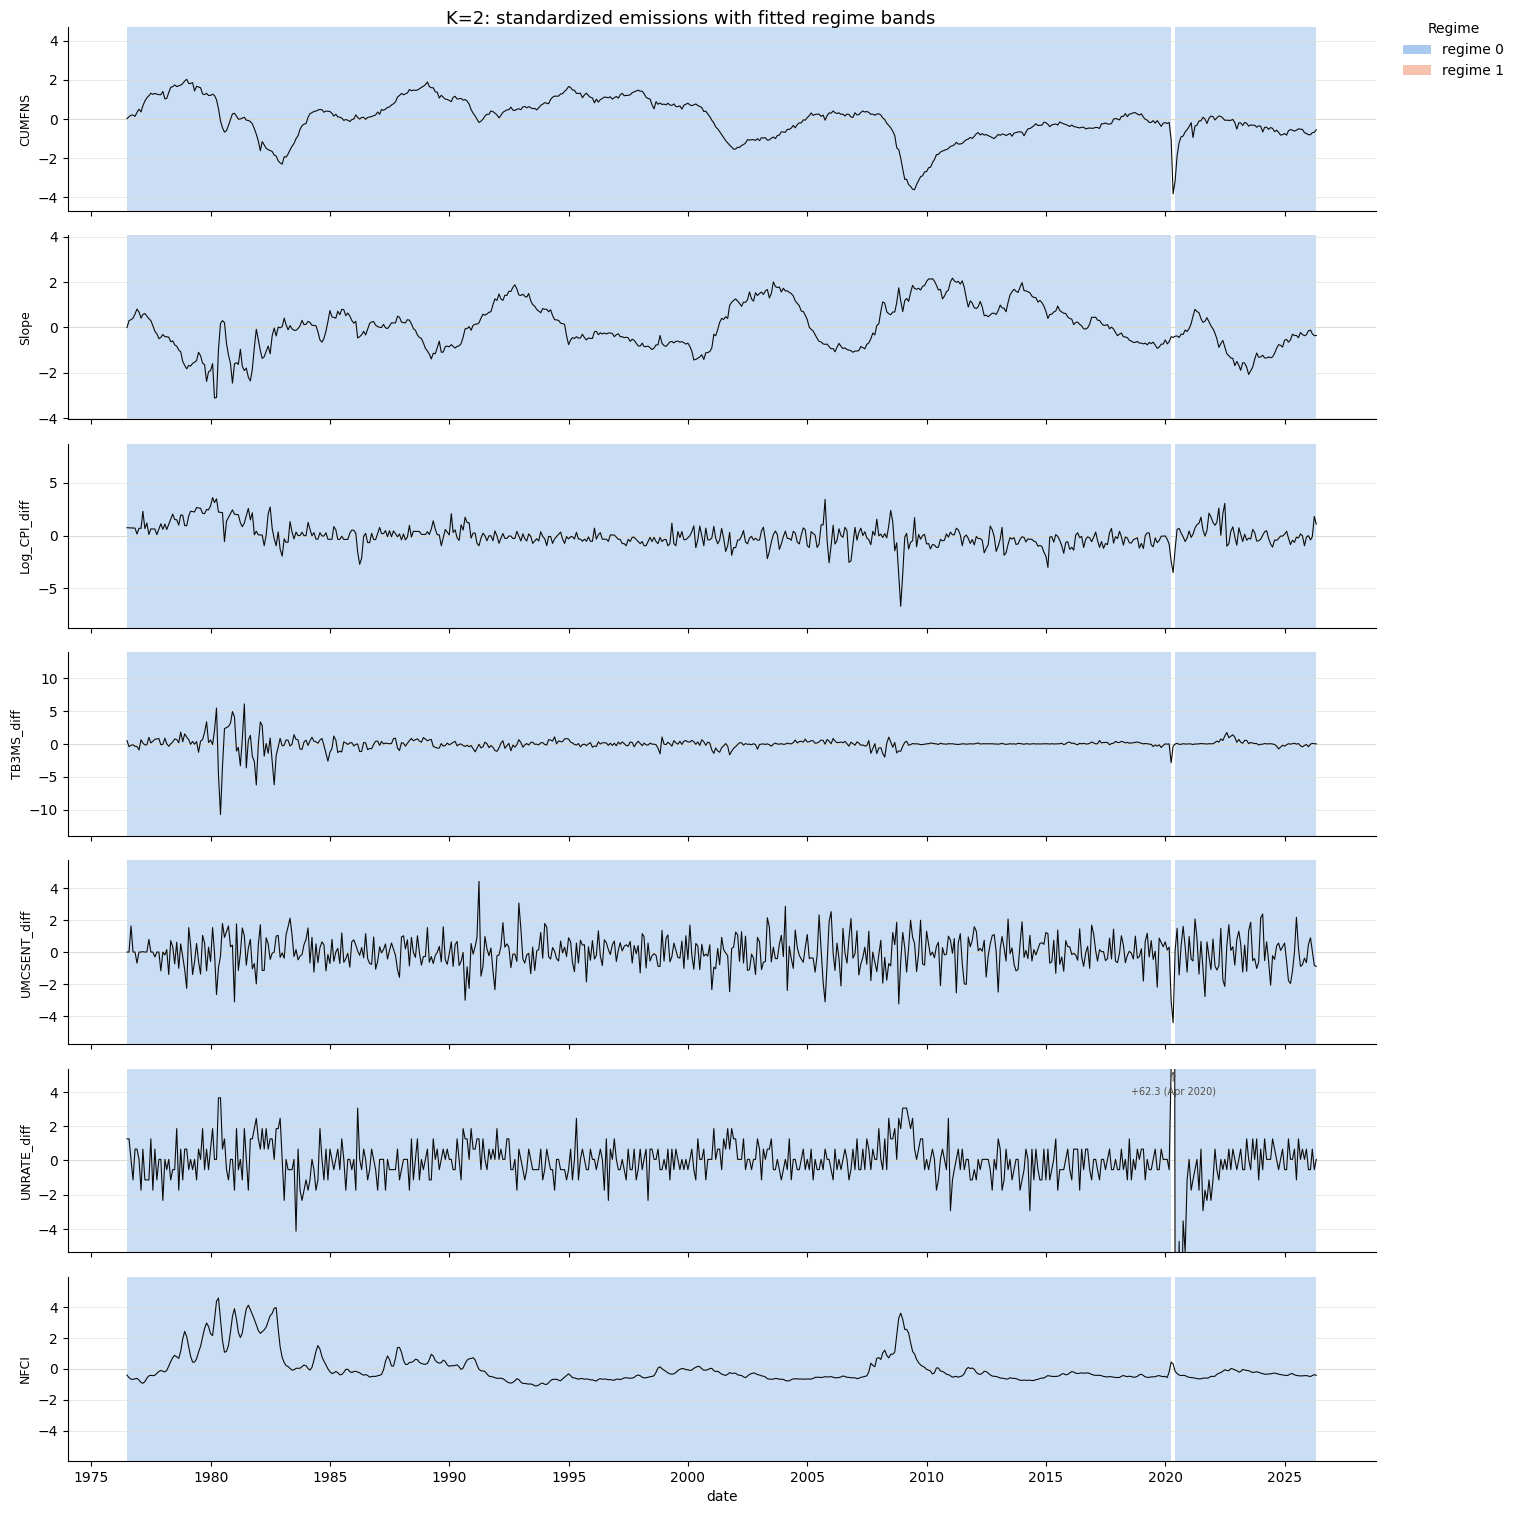

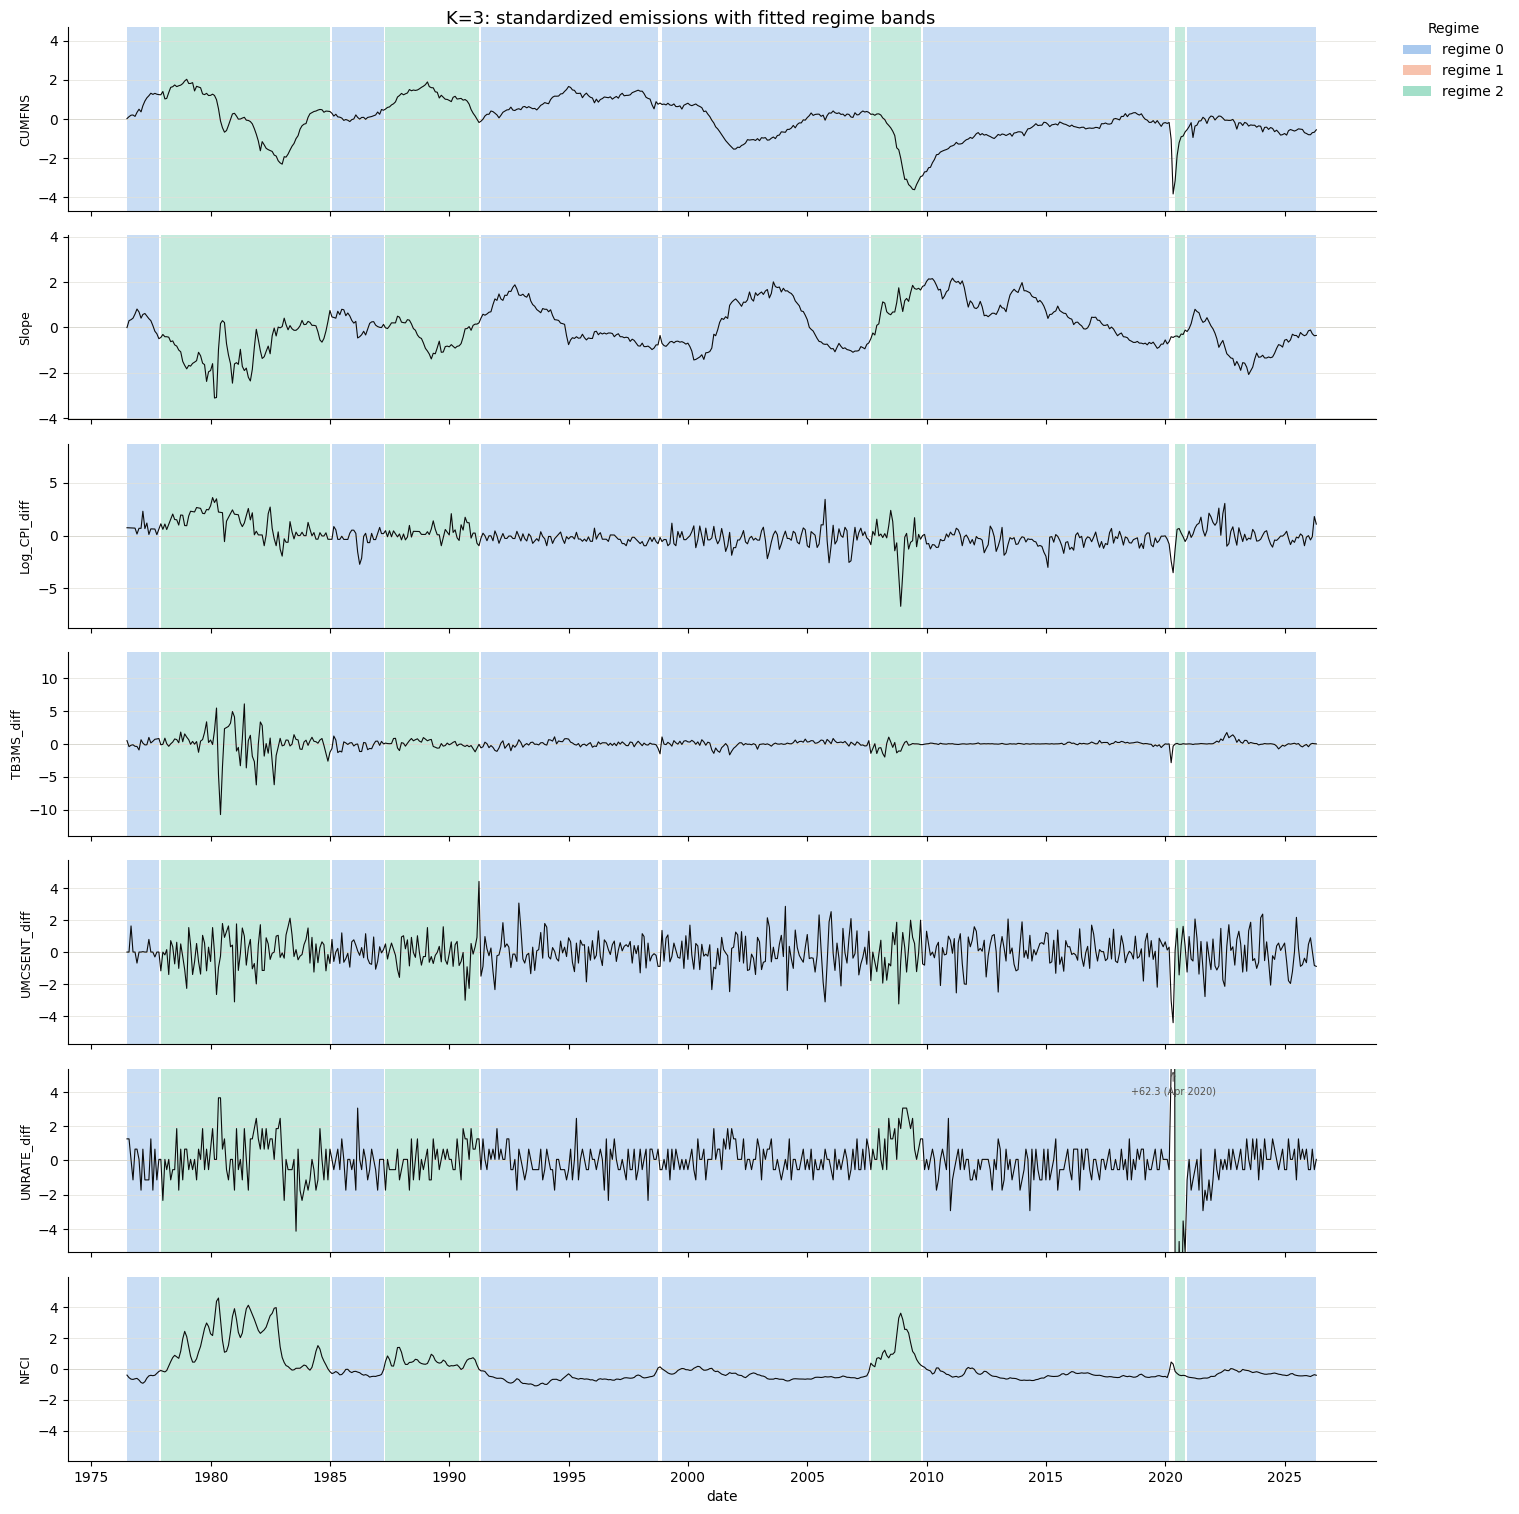

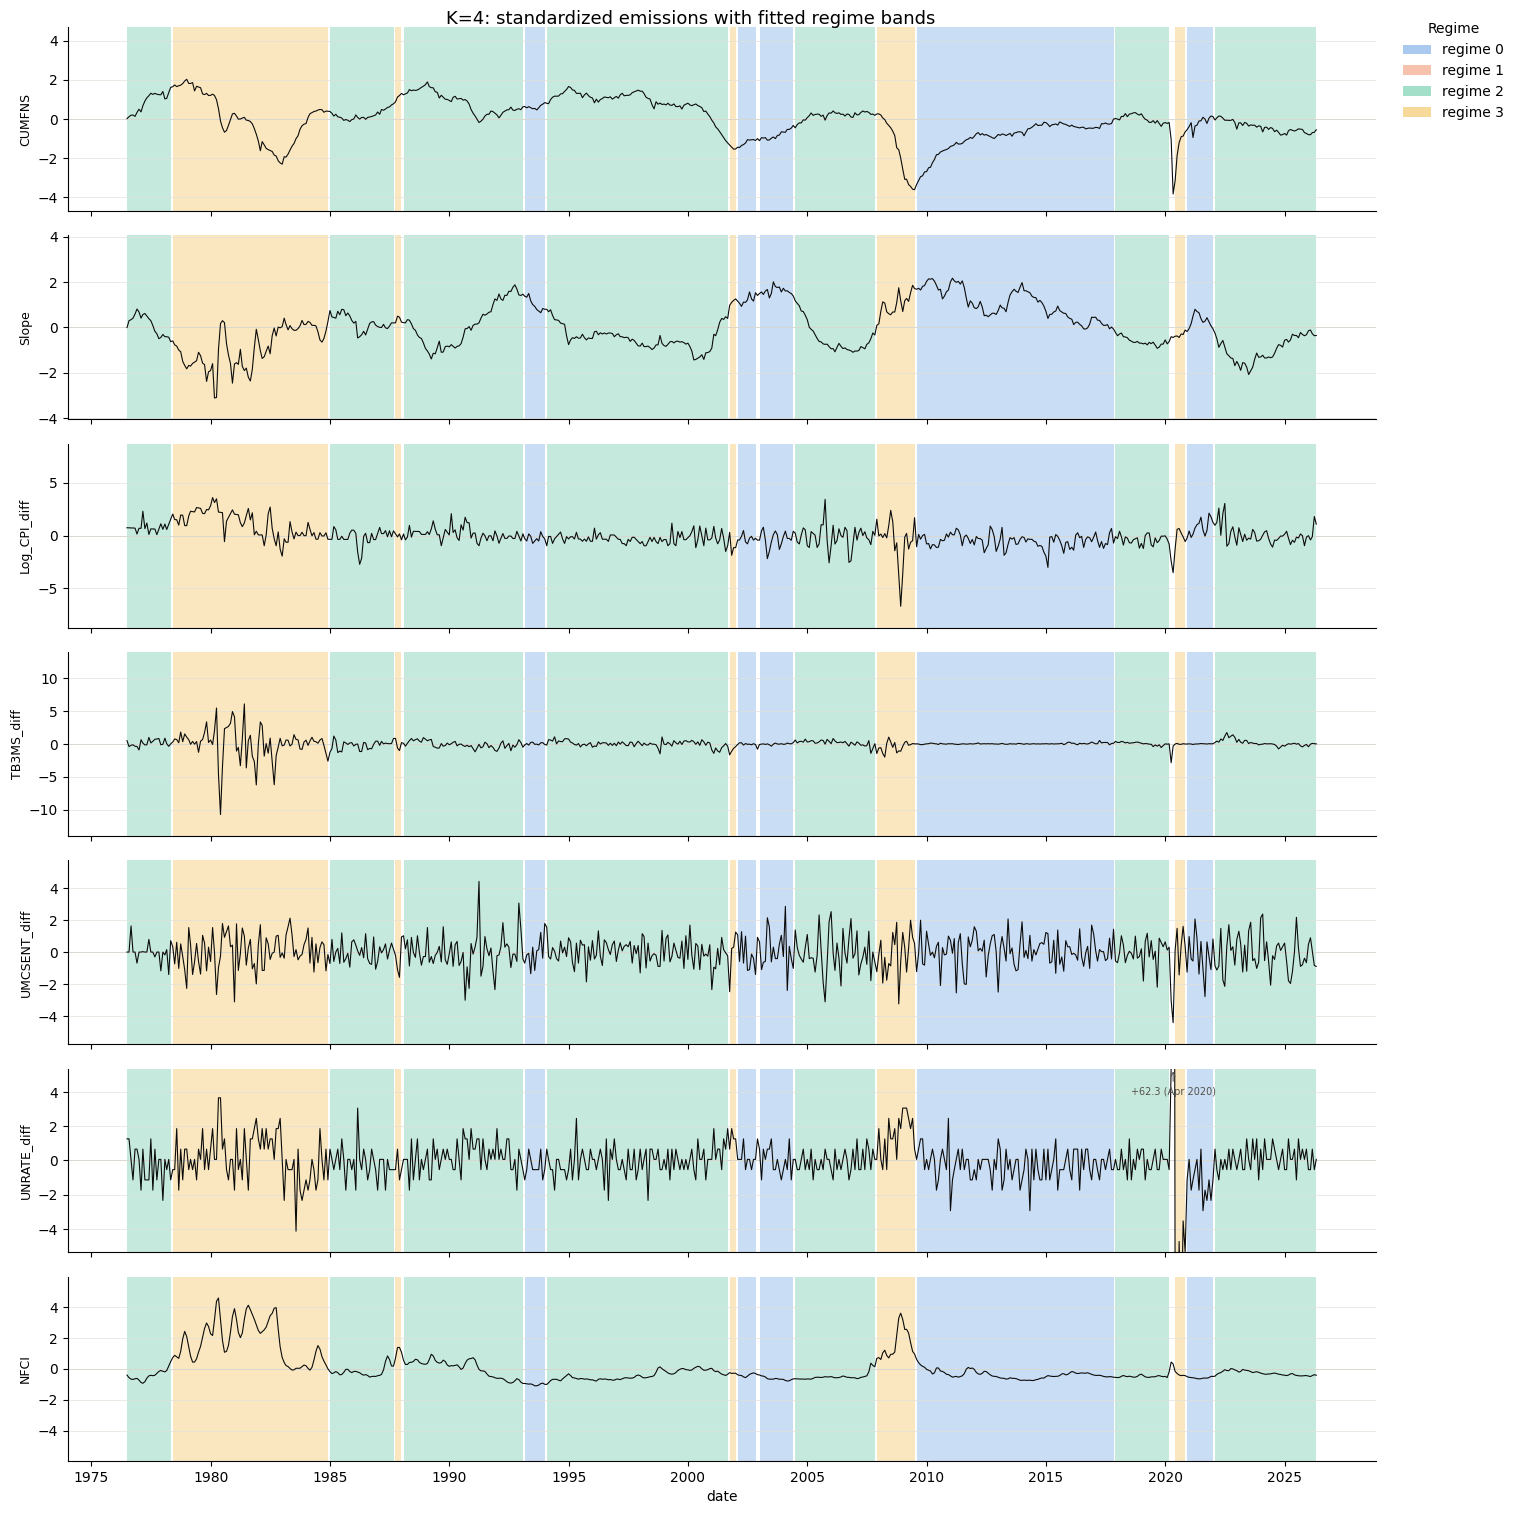

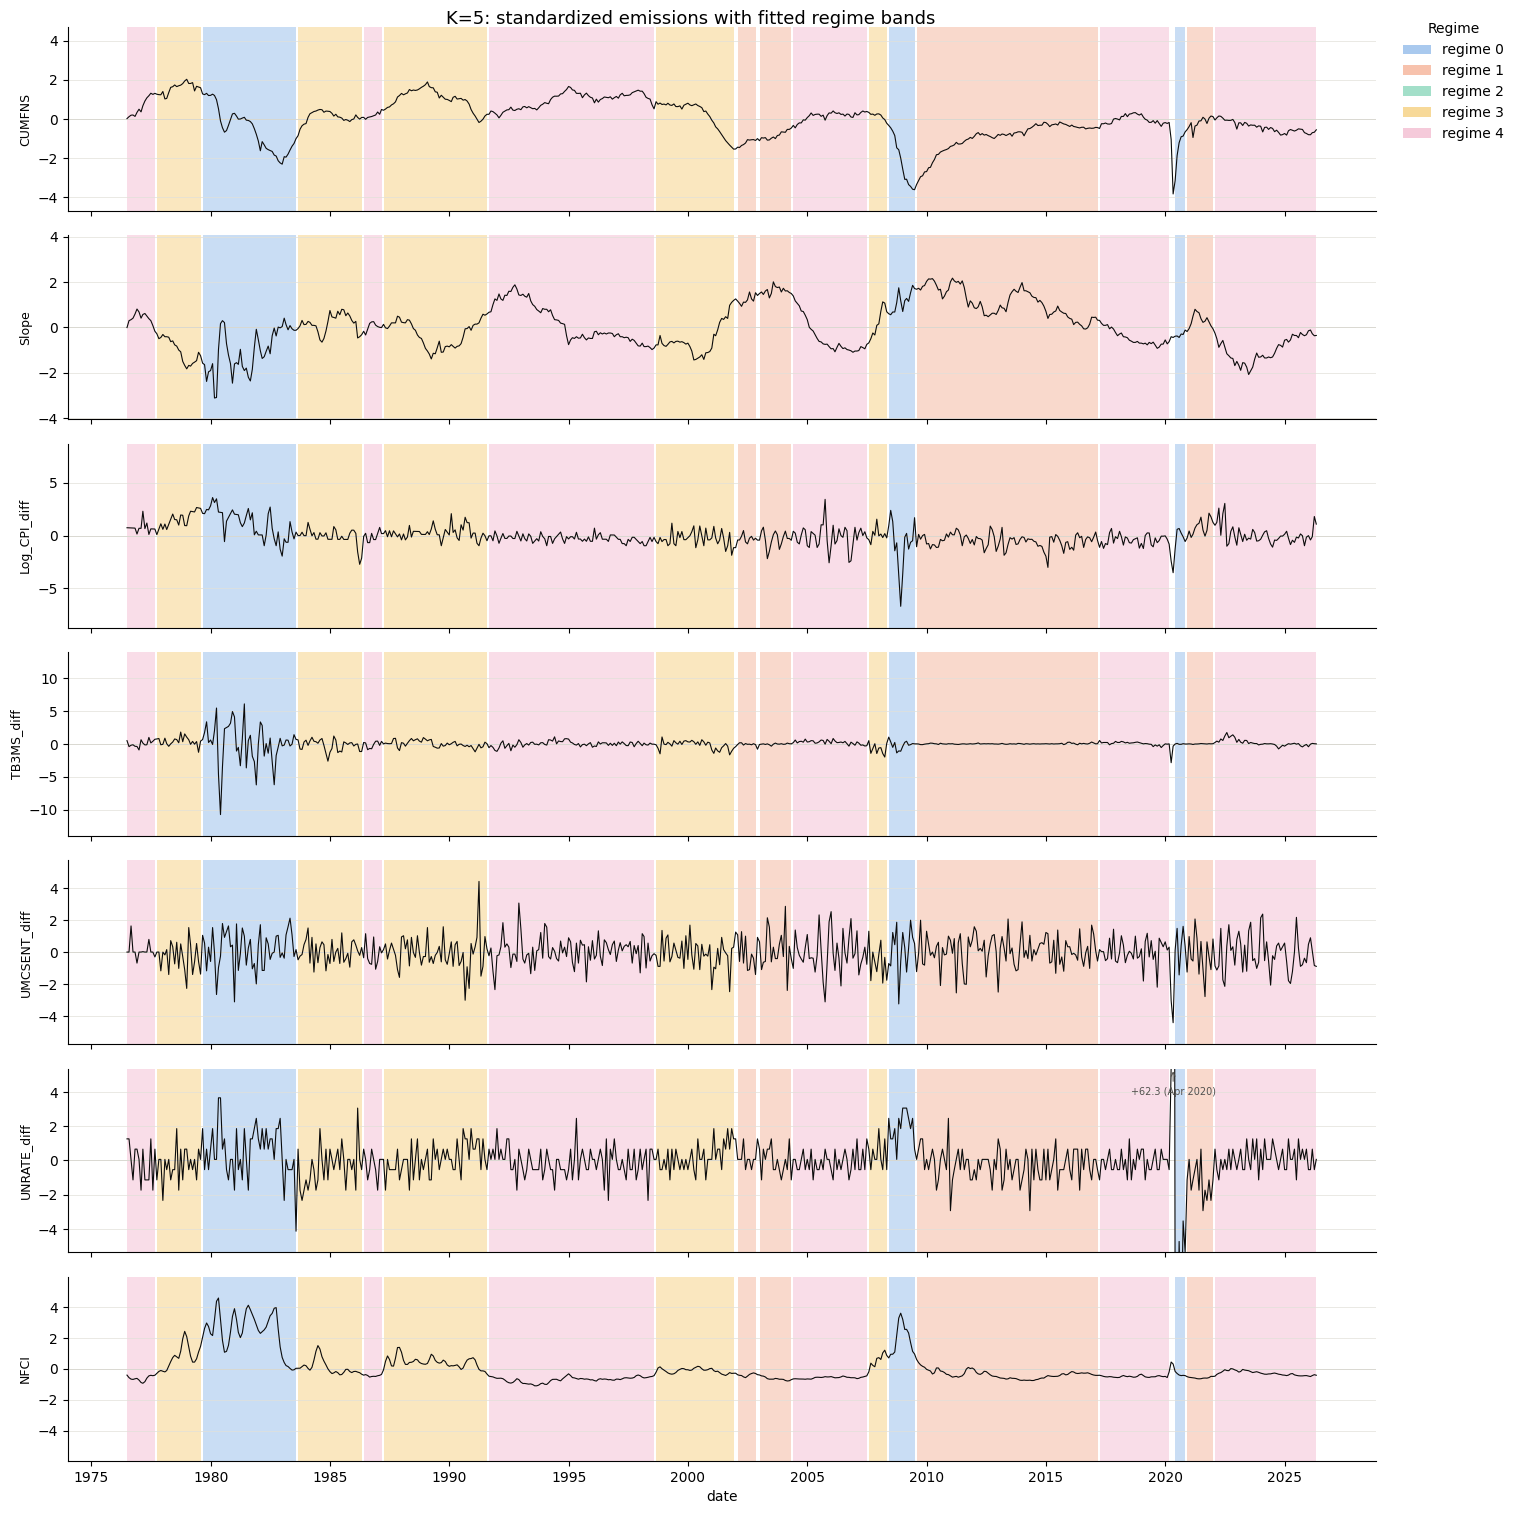

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# first 5 slots of the project's validated categorical palette, fixed order
REGIME_COLORS = {0: '#2a78d6', 1: '#eb6834', 2: '#1baf7a', 3: '#eda100', 4: '#e87ba4'}


def contiguous_regime_blocks(path, dates):
    blocks = []
    start_idx = 0
    for t in range(1, len(path) + 1):
        if t == len(path) or path[t] != path[start_idx]:
            blocks.append((path[start_idx], dates[start_idx], dates[t - 1]))
            start_idx = t
    return blocks


def shade_regimes(ax, blocks):
    for regime, start, end in blocks:
        ax.axvspan(start, end, color=REGIME_COLORS[regime], alpha=0.25, lw=0, zorder=0)


def robust_ylim(series, pad=1.3):
    # size the axis to the non-COVID range so one ~60-sigma COVID month
    # (UNRATE_diff) doesn't flatten the other 598 months to a flat line
    non_covid_max = series[~covid_mask].abs().max()
    return -non_covid_max * pad, non_covid_max * pad


def annotate_offscale(ax, series, ylo, yhi):
    if series.max() <= yhi and series.min() >= ylo:
        return
    peak_date = series.idxmax() if series.max() > yhi else series.idxmin()
    peak_val = series.loc[peak_date]
    y_edge = yhi if peak_val > 0 else ylo
    ax.annotate(f'{peak_val:+.1f} ({peak_date:%b %Y})', xy=(peak_date, y_edge),
                xytext=(peak_date, y_edge * 0.8), ha='center',
                va='top' if peak_val > 0 else 'bottom', fontsize=7, color='#52514e',
                arrowprops=dict(arrowstyle='->', color='#52514e', lw=0.7))


for K in K_CANDIDATES:
    path = fitted_models[K].predict(observations)
    blocks = contiguous_regime_blocks(path, emissions_df.index)

    fig, axes = plt.subplots(len(EMISSION_COLS), 1, figsize=(14, 2.2 * len(EMISSION_COLS)), sharex=True)

    for ax, col in zip(axes, EMISSION_COLS):
        series = emissions_z[col]
        shade_regimes(ax, blocks)
        ax.plot(emissions_df.index, series, color='#0b0b0b', linewidth=0.8)
        ax.axhline(0, color='#c3c2b7', linewidth=0.6, zorder=0)

        ylo, yhi = robust_ylim(series)
        ax.set_ylim(ylo, yhi)
        annotate_offscale(ax, series, ylo, yhi)

        ax.set_ylabel(col, fontsize=9)
        ax.grid(axis='y', color='#e1e0d9', linewidth=0.5, zorder=0)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[-1].set_xlabel('date')

    legend_handles = [Patch(facecolor=REGIME_COLORS[k], alpha=0.4, label=f'regime {k}') for k in range(K)]
    fig.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.0, 0.98), frameon=False, title='Regime')
    fig.suptitle(f'K={K}: standardized emissions with fitted regime bands', fontsize=13)
    plt.tight_layout()
    plt.show()


## Economic interpretation

##### K = 4 (COVID + 3 regimes)

- Expansion (331 months, regime 2) - default growth
- Recovery (153 months, regime 0) - 2009-2017 financial crisis recovery, post-COVID bounce
- Tightening/Stress (114 months, regime 3) - Volcker 1978-1984 aggressive hikes, Black Monday 1987, 2001, 2007-2008 financial crisis, COVID panic following April
- COVID (1 month, regime 1) 

##### K = 5

- Expansion (235 months, regime 4) - default growth
- Recovery (133 months, regime 1) - 2009-2017 financial crisis recovery, post-COVID bounce
- Stress regimes:
                regime 0 - Acute stress takes the worst parts of financial crisis, Volcker, COVID
                regime 3 - early financial crisis, 1998-2001 (as didn't have as obvious impact on macroeconomy), but this is capturung a lot of normality
- COVID (1 month, regime 2) 


###### CONCLUSION

K=4 is the only reasonable option, normality is interpreted as stress in k=5

In [7]:
# check whether every regime actually appears in the Viterbi path, and how often
for K in K_CANDIDATES:
    path = fitted_models[K].predict(observations)
    counts = np.bincount(path, minlength=K)
    print(f"K={K}: regime counts = {counts}  (months out of {len(path)})")


K=2: regime counts = [598   1]  (months out of 599)
K=3: regime counts = [430   1 168]  (months out of 599)
K=4: regime counts = [153   1 331 114]  (months out of 599)
K=5: regime counts = [ 71 133   1 159 235]  (months out of 599)


In [8]:
D = observations.shape[1]
n = observations.shape[0]


def count_free_params(K, D):
    n_startprob = K - 1
    n_transmat = K * (K - 1)
    n_means = K * D
    n_covars = K * D * (D + 1) // 2
    return n_startprob + n_transmat + n_means + n_covars


results = []
for K in K_CANDIDATES:
    ll = fitted_models[K].score(observations)
    p = count_free_params(K, D)
    aic = 2 * p - 2 * ll
    bic = p * np.log(n) - 2 * ll
    results.append({'K': K, 'log_likelihood': ll, 'n_params': p, 'AIC': aic, 'BIC': bic})

results_df = pd.DataFrame(results).set_index('K')
print(results_df.round(2))


   log_likelihood  n_params       AIC       BIC
K                                              
2        -5784.46        73  11714.93  12035.78
3        -4628.49       113   9482.99   9979.65
4        -4241.72       155   8793.44   9474.70
5        -3860.58       199   8119.15   8993.81


## K selection 

We don't want an extreme number of regimes. As the COVID regime takes up a single month we look towards 4/5 regimes.

These will be tested using our validaiton techniques, K=4 seems the most appropriate

We see 38.4% of months are considered stress with k=5. Can't be justifiable.

## Numerical stability

By observing the transition matrix, it is clear the row and column for the COVID shock are ridiculous. 1 month of data, no observed persistence, based on sticky prior.

We conclude it is essentially k=3 with a joke of a state (one that I want to keep)

Omitting the COVID shock state we have a negative definite Hessian as required :)

In [9]:
import copy

K = 4
REF = 0
FD_EPS = 1e-4

model = fitted_models[K]


def transmat_to_logits(transmat, ref=REF, floor=1e-10):
    Kd = transmat.shape[0]
    other_cols = [c for c in range(Kd) if c != ref]
    P = np.clip(transmat, floor, 1.0)
    return np.log(P[:, other_cols] / P[:, [ref]]).ravel()


def logits_to_transmat(theta, Kd, ref=REF):
    other_cols = [c for c in range(Kd) if c != ref]
    theta_mat = theta.reshape(Kd, Kd - 1)
    exp_mat = np.exp(theta_mat)
    denom = 1.0 + exp_mat.sum(axis=1, keepdims=True)
    P = np.zeros((Kd, Kd))
    P[:, ref] = (1.0 / denom).ravel()
    for col_idx, c in enumerate(other_cols):
        P[:, c] = exp_mat[:, col_idx] / denom.ravel()
    return P


def finite_diff_hessian(f, theta0, eps=FD_EPS):
    p = len(theta0)
    eye = np.eye(p)
    f0 = f(theta0)
    f_plus = np.array([f(theta0 + eps * eye[i]) for i in range(p)])
    f_minus = np.array([f(theta0 - eps * eye[i]) for i in range(p)])
    H = np.zeros((p, p))
    np.fill_diagonal(H, (f_plus - 2 * f0 + f_minus) / eps**2)
    for i in range(p):
        for j in range(i + 1, p):
            fpp = f(theta0 + eps * eye[i] + eps * eye[j])
            fpm = f(theta0 + eps * eye[i] - eps * eye[j])
            fmp = f(theta0 - eps * eye[i] + eps * eye[j])
            fmm = f(theta0 - eps * eye[i] - eps * eye[j])
            H[i, j] = H[j, i] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
    return H


theta_star = transmat_to_logits(model.transmat_)
working = copy.deepcopy(model)


def loglik(theta):
    working.transmat_ = logits_to_transmat(theta, K)
    return working.score(observations)


H = finite_diff_hessian(loglik, theta_star)
eigvals, eigvecs = np.linalg.eigh(H)

print("eigenvalues:", eigvals)
print("negative definite:", bool(np.all(eigvals < 0)))

other_cols = [c for c in range(K) if c != REF]
labels = [(i, c) for i in range(K) for c in other_cols]

for idx, val in enumerate(eigvals):
    if val >= 0:
        vec = eigvecs[:, idx]
        loadings = sorted(zip(labels, vec), key=lambda x: -abs(x[1]))
        print(f"\nnon-negative eigenvalue[{idx}] = {val:.6f}")
        for (src, dst), w in loadings:
            print(f"  ({src} -> {dst}): {w:+.4f}")


eigenvalues: [-1.19040026e+01 -6.96878123e+00 -4.67502992e+00 -1.51156563e+00
 -8.90998597e-01 -5.82310951e-01 -2.77805166e-01 -5.52882082e-05
 -1.31240542e-05  2.22850737e-09  8.43962784e-06  1.96411610e-04]
negative definite: False

non-negative eigenvalue[9] = 0.000000
  (1 -> 2): +0.6668
  (2 -> 1): +0.6666
  (0 -> 1): -0.3333
  (1 -> 3): +0.0001
  (1 -> 1): -0.0000
  (2 -> 3): +0.0000
  (0 -> 3): -0.0000
  (2 -> 2): +0.0000
  (0 -> 2): -0.0000
  (3 -> 3): -0.0000
  (3 -> 1): -0.0000
  (3 -> 2): +0.0000

non-negative eigenvalue[10] = 0.000008
  (1 -> 2): -0.6928
  (2 -> 1): +0.5717
  (1 -> 1): -0.2572
  (1 -> 3): -0.2571
  (0 -> 1): -0.2427
  (0 -> 3): -0.0450
  (2 -> 3): +0.0000
  (2 -> 2): +0.0000
  (3 -> 2): +0.0000
  (0 -> 2): -0.0000
  (3 -> 3): +0.0000
  (3 -> 1): -0.0000

non-negative eigenvalue[11] = 0.000196
  (0 -> 3): +0.9649
  (0 -> 1): +0.2234
  (2 -> 1): +0.1176
  (1 -> 1): -0.0512
  (1 -> 3): -0.0511
  (1 -> 2): -0.0059
  (0 -> 2): -0.0000
  (3 -> 1): -0.0000
  (3 ->

In [10]:
labels_k4 = {0: 'Recovery', 1: 'Shock', 2: 'Expansion', 3: 'Stress'}
transmat_df = pd.DataFrame(
    fitted_models[4].transmat_,
    index=[f'{i}:{labels_k4[i]}' for i in range(4)],
    columns=[f'{i}:{labels_k4[i]}' for i in range(4)],
)
print(transmat_df.round(4))


             0:Recovery  1:Shock  2:Expansion  3:Stress
0:Recovery       0.9673   0.0000       0.0327    0.0000
1:Shock          0.0000   0.8333       0.0000    0.1667
2:Expansion      0.0063   0.0000       0.9765    0.0171
3:Stress         0.0260   0.0087       0.0247    0.9406


In [11]:
K = 4
model = fitted_models[K]
labels_k4 = {0: 'Recovery', 1: 'Shock', 2: 'Expansion', 3: 'Stress'}

path = model.predict(observations)
T = len(path)

actual_months = np.bincount(path, minlength=K)

p_ii = np.diag(model.transmat_)
expected_duration = 1.0 / (1.0 - p_ii)

eigvals, eigvecs = np.linalg.eig(model.transmat_.T)
idx = np.argmin(np.abs(eigvals - 1))
stationary = np.real(eigvecs[:, idx])
stationary = stationary / stationary.sum()

persistence_df = pd.DataFrame({
    'actual_months': actual_months,
    'actual_pct': 100 * actual_months / T,
    'expected_duration': expected_duration,
    'stationary_pct': 100 * stationary,
    'stationary_months': stationary * T,
}, index=[f'{i}:{labels_k4[i]}' for i in range(K)])

print(persistence_df.round(2))


             actual_months  actual_pct  expected_duration  stationary_pct  \
0:Recovery             153       25.54              30.61           25.46   
1:Shock                  1        0.17               6.00            0.97   
2:Expansion            331       55.26              42.62           55.00   
3:Stress               114       19.03              16.83           18.56   

             stationary_months  
0:Recovery              152.52  
1:Shock                   5.81  
2:Expansion             329.47  
3:Stress                111.20  
